# Predict density of embeddings for genomic loci

Here we present basics for inference using DNase model.<br>
It's possible to use full model or model's trunk to predict density or model's embeddings.<br> 
You can generate predictions for either a single sequence or multiple sequences.

## Imports 

In [ ]:
from os.path import exists
from io import StringIO
from IPython.display import display

import numpy as np
import pandas as pd
import torch

from genome_tools.genomic_interval import GenomicInterval
from genome_tools.data.extractors import FastaExtractor
from genome_tools.data.anndata import read_zarr_backed
from vinson.utils.sequence_utils import one_hot_encode
from vinson.utils.inference import InferenceDatasetConfig, score_bed_with_dhs_model
from vinson.from_config import read_configs, dhs_model_from_config
from vinson.postprocessing.interpretation import ModelWrapper

from genome_tools.plotting.ideogram import read_ideogram
from genome_tools.plotting.modular_plot import IntervalPlotter
from genome_tools.plotting.modular_plot.plot_components.prediction import PredictedSignalComponent
from genome_tools.plotting.modular_plot.plot_components.basic import TrackComponent, IdeogramComponent, GencodeComponent


findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
## configure your graph
rcParams["axes.titlesize"] = "large"
rcParams["axes.titlepad"] = 2

rcParams["axes.linewidth"] = 0.5
rcParams["axes.labelsize"] = "medium"
rcParams["axes.labelpad"] = 1

rcParams["xtick.labelsize"] = "medium"
rcParams["ytick.labelsize"] = "medium"

rcParams["xtick.major.size"] = 2
rcParams["ytick.major.size"] = 2
rcParams["xtick.major.width"] = 0.5
rcParams["ytick.major.width"] = 0.5
rcParams["xtick.major.pad"] = 1
rcParams["ytick.major.pad"] = 1

rcParams["grid.linewidth"] = 0.5

rcParams["legend.fontsize"] = "medium"
rcParams["legend.labelspacing"] = 0.5

rcParams["font.size"] = 6

rcParams["lines.linewidth"] = 0.75


rcParams['figure.dpi'] = 300

## Set up your paths

In [3]:
# we provide with example bed to score with model
str_bed = """chr6\t3279110\t3280454
chr18\t2571385\t2572729
chr3\t64163341\t64164685
chr3\t136134521\t136135865
chr10\t114094430\t114095774
chr16\t70454157\t70455501
chr10\t106712965\t106714309
chr5\t75648340\t75649684"""

In [ ]:
device = 'cuda:1'

fasta_file = '/mnt/calc/sbushuev/genomes/hg38/hg38.fa' # genome
gencode_annotation_file = '/mnt/calc/sbushuev/genomes/hg38/gencode.v49.basic.annotation.sorted.gff3.gz' #'/mnt/calc/sbushuev/genomes/hg38/gencode.v49.basic.annotation.sorted.gff3.gz'
idg_path = ''

zarr_anndata_path = '/mnt/calc/sbushuev/dhs_project/anndata/reference_anndata.human.stripped_layers.zarr'
embed_path = '/mnt/calc/homes/sbushuev/dhs_project/embeds/data.all.tsv'
embed_meta_path = '/mnt/calc/homes/sbushuev/dhs_project/embeds/meta.all.tsv'
genotype_file = '/mnt/calc/sbushuev/dhs_project/JUN29/all_variants_stats.trimmed_cols.bed.gz'

##paths to model's config .yaml file used to train model and model weights
config_path= '/mnt/calc/homes/sbushuev/dhs_project/configs/FinalVersion/MAR06_8mln_long.yaml' # 
checkpoint_path = '/mnt/calc/homes/sbushuev/dhs_project/checkpoints/9epochs_8mln_JUN29_best_epoch=8.ckpt'

## load files in case you don't have them locally
if not exists(zarr_anndata_path):
    zarr_anndata_path = 'https://regulome.altius.org/data/release_20260818/human/consensus_dhs/human_reference/human_reference_anndata.zarr/'
if not exists(idg_path):
    idg_path = 'https://resources.altius.org/~sabramov/collaborations/vinson/examples/cytoBandIdeo.txt'


## Load and use DNase-seq model <br>to predict density for a single sequence

Our model predicts based on one-hot-encoded nucleotide sequence and sample embeddings<br>
which you can extract from anndata, load separate tab-delimited table or calculate using first notebook.  

In [5]:
## set up model
config = read_configs(config_path)
model = dhs_model_from_config(config, checkpoint_path = checkpoint_path).eval().to(device) #L.LightningModule

embed_df = pd.read_table(embed_path, index_col=0)
embed_meta_df = pd.read_table(embed_meta_path, index_col=0)

/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


### Get cell context aware predictions
Calculate sequence sensitivity to DNase in the cell-type context for your genomic sequence  

In [ ]:
## your dna sequence
half_seqlen = 1344/2
## select genomic loci
interval = GenomicInterval.from_ucsc('chr2:60495243-60495243').center.widen(half_seqlen) 
fasta_extr = FastaExtractor(fasta_file)
seq = fasta_extr[interval].upper() # extract sequence

##select sample and its embedding
chosen_term = 'HUDEP-2'
embed_id = embed_meta_df.loc[embed_meta_df.core_ontology_term == chosen_term].index.values[0] # chose one sample
embed = embed_df.loc[embed_id].values

## convert to torch.Tensor and reshape to mimic batch
ohe_seq = torch.as_tensor(one_hot_encode(seq), device=device, dtype=torch.float32)[None,:, :]
embed = torch.as_tensor(embed, device=device, dtype=torch.float32)[None,:]

## get your prediction
pred = model(ohe_seq, embed)
print(pred)

/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/torch/nn/modules/conv.py:304: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /opt/conda/conda-bld/pytorch_1724789220573/work/aten/src/ATen/native/Convolution.cpp:1031.)
  return F.conv1d(input, weight, bias, self.stride,


tensor([[3.4821]], device='cuda:1', grad_fn=<SoftplusBackward0>)


### Calculate cell-type specific embeddings for downstream applications
you can use model's trunk to extract sequence embeddings

In [7]:
## get model's trunk to calculate model's embedding
trunk_model = model.trunk_model # nn.Module
model_embeddings = trunk_model(ohe_seq, embed)

print(model_embeddings.shape)

torch.Size([1, 528])


## Predict tracks

select samples and predict density tracks for them with 20 bp step 

In [8]:
idg = read_ideogram(idg_path)
anndata = read_zarr_backed(zarr_anndata_path)

/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing sparse_dataset from `anndata.experimental` is deprecated. Import anndata.io.sparse_dataset instead.
  warnings.warn(msg, FutureWarning)
/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/mnt/calc/sbushuev/.conda/

In [ ]:
## set up model
model_config = read_configs(config_path)
model_predict = dhs_model_from_config(model_config, checkpoint_path).to(device)
model_wrapper = ModelWrapper(model_predict).eval()

## choose intervals and samples to draw for
intervals = [GenomicInterval.from_ucsc('chr2:60495243-60495243').center]
chosen_samples = ['AG95384', 'AG80853'] 

## load true profile
base_path = 'https://regulome.altius.org/data/per_sample/' 
online_track_path = [
    base_path+ s + '/' + s + '.normalized_density.bw' 
    for s in chosen_samples]

/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [ ]:
## compose your graph

annotation_components = [
    ## ideogram component with inteval's chromosome position annotation
    IdeogramComponent(
        interval_key='big',
        height=0.1, # height, handled by IntervalPlotter, by default, in inches,
        margins=0
    ),
    ## annotate your graph based on genomic annotation
    GencodeComponent(
        interval_key='big',
        height=0.03,
        margins=(0, 0.02)
    )] 
track_components = [
   [    ## plot true profile 
       TrackComponent(
        name=f'TrueSignalComponent_{s}',
        signal_file = online_track_path[idx],
        interval_key='med',
        color='tab:blue',
        height=0.5,
        margins=(0.05,0.1)),
        ## plot predicted profile
        PredictedSignalComponent(
        name=f'PredictedSignalComponent_{s}',
        interval_key='med',
        sample_id=s,
        color='tab:orange',
        height=0.5,
        margins=(0.05,0.1))
        ]
        
            for idx, s in enumerate(chosen_samples)
         ]

plot_components = annotation_components + sum(track_components, [])

interval_plotter = IntervalPlotter(
    plot_components=plot_components,
    anndata=anndata,
    model_config=model_config,
    model_wrapper=model_wrapper,
    fasta_file=fasta_file,
    ideogram_data=idg,
    gencode_annotation_file=gencode_annotation_file,
)

Found overlapping component loader kwargs:
Argument 'signal_file' used by: TrueSignalComponent_AG95384, PredictedSignalComponent_AG95384, TrueSignalComponent_AG80853, PredictedSignalComponent_AG80853
Argument 'model_wrapper' used by: PredictedSignalComponent_AG95384, PredictedSignalComponent_AG80853
Argument 'interp1d_kind' used by: PredictedSignalComponent_AG95384, PredictedSignalComponent_AG80853
Argument 'sample_id' used by: PredictedSignalComponent_AG95384, PredictedSignalComponent_AG80853
Argument 'anndata' used by: PredictedSignalComponent_AG95384, PredictedSignalComponent_AG80853
Argument 'fasta_file' used by: PredictedSignalComponent_AG95384, PredictedSignalComponent_AG80853
Argument 'genotype_file' used by: PredictedSignalComponent_AG95384, PredictedSignalComponent_AG80853
Argument 'step' used by: PredictedSignalComponent_AG95384, PredictedSignalComponent_AG80853


In [ ]:
seqlen = 4000
plotter_data_bundle = []

for reg in intervals:
    reg = reg.widen(seqlen)
    plotter_data = interval_plotter.get_interval_data(
        interval={
            'small': reg,
            'big': reg,
            'med': reg,
        },
        step=20,
    )
    plotter_data_bundle.append(plotter_data)

Loading data: 100%|██████████| 6/6 [00:17<00:00,  2.88s/it]


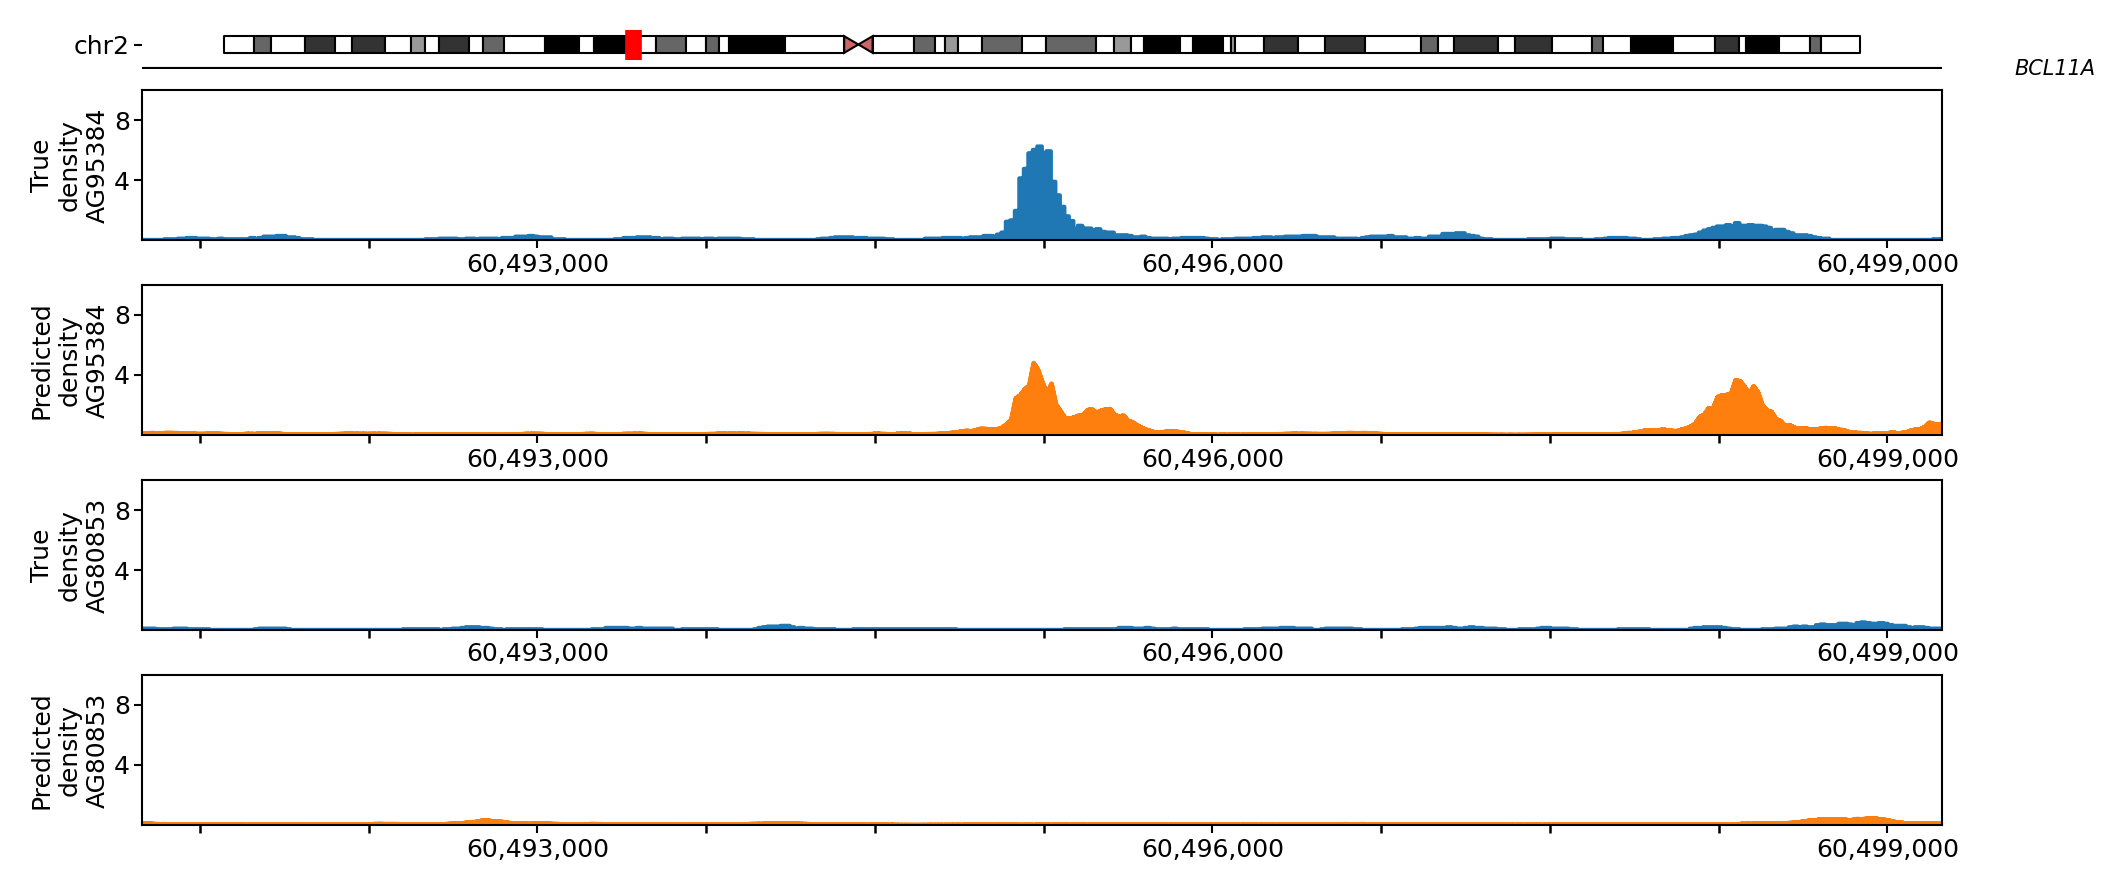

In [ ]:
for plotter_data in plotter_data_bundle:
    axes = interval_plotter.plot_interval(plotter_data, fig_width=6)

    for idx, ax in enumerate(axes[2:]):
        ax.set_ylim(0,10)
        sample_idx = idx//2

        if idx %2 == 0:
            ax.set_ylabel(f'True\ndensity\n{chosen_samples[sample_idx]}')
        else:
            ax.set_ylabel(f'Predicted\ndensity\n{chosen_samples[sample_idx]}')

plt.show()

## Score your bed file
You can use either trunk or full model to calculate embeddings or density. <br>
It's possible to predict for shifted intervals. To enable it you must pass *ArrayLike* with shifts. 

In [ ]:
## load your data
embed_df = pd.read_table(embed_path, index_col=0)
bed_df = pd.read_table(StringIO(str_bed), header=None,
                       names=['chrom', 'start', 'end'])

## Select samples
selected_samples = ['AG3897']
embed_df = embed_df.loc[selected_samples]
shifts = [-10, 0, 10] ## select shifts for test time augmentation

## establish config for inference
dataset_kwargs = InferenceDatasetConfig(embed_df=embed_df,
                                        bed_df=bed_df,
                                        shifts=shifts,
                                        fasta_file=fasta_file)
## prepare kwargs for dataloader
dataloader_kwargs = dict(batch_size=256, 
                    num_workers=2, 
                    pin_memory=True, 
                    shuffle=False)

In [ ]:
## load model
config = read_configs(config_path)
model = dhs_model_from_config(config, checkpoint_path = checkpoint_path).eval().to(device)
trunk_model = model.trunk_model ## so here we're using trunk model to get embeddings

/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


### Calculate cell-type aware embeddings of genomic loci

In [ ]:
## use trunk model to extract embeddings with 528 coordinates 
meta_out, preds = score_bed_with_dhs_model(inference_dataclass=dataset_kwargs,
                                           model=trunk_model,
                                           dataloader_kwargs=dataloader_kwargs,
                                           device=device)

display(meta_out.head())
print(f'Your predictions\' shape: {preds.shape}')

  0%|          | 0/1 [00:00<?, ?it/s]

,chrom,start,end,shift,embed_id
0,chr6,3279110,3280454,-10,AG3897
1,chr18,2571385,2572729,-10,AG3897
2,chr3,64163341,64164685,-10,AG3897
3,chr3,136134521,136135865,-10,AG3897
4,chr10,114094430,114095774,-10,AG3897


Your predictions' shape: (24, 528)


### Predict densities of a multitude of sequences

In [ ]:
## use full model
meta_out, preds = score_bed_with_dhs_model(inference_dataclass=dataset_kwargs,
                                           model=model, 
                                           dataloader_kwargs=dataloader_kwargs,
                                           device=device)

display(meta_out.head())
print(f'Your predictions\' shape: {preds.shape}')

  0%|          | 0/1 [00:00<?, ?it/s]

,chrom,start,end,shift,embed_id
0,chr6,3279110,3280454,-10,AG3897
1,chr18,2571385,2572729,-10,AG3897
2,chr3,64163341,64164685,-10,AG3897
3,chr3,136134521,136135865,-10,AG3897
4,chr10,114094430,114095774,-10,AG3897


Your predictions' shape: (24, 1)


Raw output table might be very large for large range of shifts and multidute of chosen samples, be carefull.

### Aggregate your predictions however you want: across samples, across shifts, etc

In [ ]:
## here we use geom mean to aggregate only across shifted sequences
meta_out['vinson.score'] = np.log(preds)
aggr_df = meta_out.groupby(['chrom', 'start', 'end','embed_id' ], observed=True ).agg(
    {'vinson.score':'mean'}
).reset_index()
aggr_df['vinson.score'] = np.exp(aggr_df['vinson.score'])

aggr_df.head()

,chrom,start,end,embed_id,vinson.score
0,chr10,106712965,106714309,AG3897,0.031269
1,chr10,114094430,114095774,AG3897,0.028603
2,chr16,70454157,70455501,AG3897,0.323638
3,chr18,2571385,2572729,AG3897,0.153401
4,chr3,64163341,64164685,AG3897,0.125875


## Inject genotypes

Our framework supports injecting of all genetic variants that you discovered. <br>
To enable it you must provide your **tab-delimited genotype_file** without header with following columns:<br>
chromosome, pos, pos+1, ref, alt, indiv_id of individual in which variant was detected and allele dosage. <br>
**Note:** you with genotype file you must provide **tab-delimited meta table for embeddings (embed_meta_df....)**<br> 
that must has first column with sample_id for which you have embeddings with motif activities <br>and inviv_id column that matches to column in genotype file. 

In [ ]:
embed_meta = pd.read_table(embed_meta_path, index_col=0)
dataset_kwargs = InferenceDatasetConfig(embed_df=embed_df,
                                        bed_df=bed_df,
                                        shifts=shifts,
                                        fasta_file=fasta_file,
                                        embed_meta_df=embed_meta,
                                        genotype_file=genotype_file)

In [20]:
meta_out, preds = score_bed_with_dhs_model(inference_dataclass=dataset_kwargs,
                                           model=model, ## use full model
                                           dataloader_kwargs=dataloader_kwargs,
                                           device=device)

display(meta_out.head())
print(f'Your predictions\' shape: {preds.shape}')

  0%|          | 0/1 [00:00<?, ?it/s]

,chrom,start,end,shift,embed_id
0,chr6,3279110,3280454,-10,AG3897
1,chr18,2571385,2572729,-10,AG3897
2,chr3,64163341,64164685,-10,AG3897
3,chr3,136134521,136135865,-10,AG3897
4,chr10,114094430,114095774,-10,AG3897


Your predictions' shape: (24, 1)
